In [ ]:
import seaborn as sns
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

In [ ]:
# Fetch file id on Drive
file_id = "1fNiz9QRSD5drWAs3k1Ji09D_u3COOJWR"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
gdown.download(url, "bank_transactions.csv", quiet=True)

# Load url
bank_df = pd.read_csv("bank_transactions.csv")

#**Isolation Forest**
Business insight:

The model identified transactions that significantly differed from normal customer behavior in terms of amount, account balance, login attempts, and transaction duration.

In [ ]:
# Get variables for anomaly detection
features = ['AccountBalance','TransactionAmount','TransactionDuration','CustomerAge','LoginAttempts']

X= bank_df[features]

In [ ]:
# Scale features
X_scaled = StandardScaler().fit_transform(bank_df[features])

In [ ]:
# Build isolation forest mode l
model_iso = IsolationForest(contamination=0.002,random_state=42)
bank_df['Anomaly'] = model_iso.fit_predict(X_scaled)

# -1 = anomaly
# 1 = normal

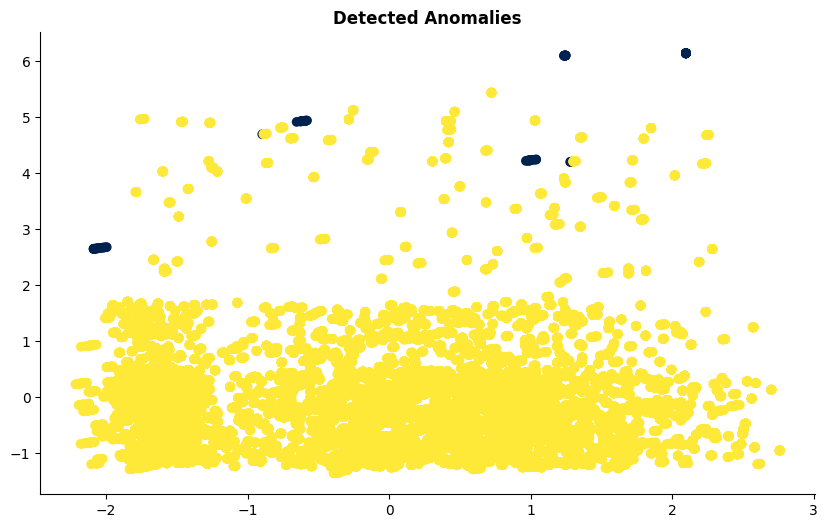

In [ ]:
# Visualize anomalies
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=bank_df['Anomaly'],cmap='cividis')

plt.title('Detected Anomalies', fontweight="bold")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [ ]:
# Show anomaly proportion
anomaly_pct = (bank_df['Anomaly'].value_counts(normalize=True).mul(100).round(2).reset_index(name='Percentage'))
anomaly_pct['Percentage'] = anomaly_pct['Percentage'].astype(str) + '%'

anomaly_pct

,Anomaly,Percentage
0,1,99.81%
1,-1,0.19%


**The Isolation Forest model identified 0.19% of transactions as anomalies, while 99.81% were classified as normal.**

<br></br>

###**Local Outlier Factor**

In [ ]:
# Local Outlier Factor model
lof = LocalOutlierFactor(n_neighbors=20,contamination=0.002)

#
bank_df['lof_anomaly'] = lof.fit_predict(X_scaled)

lof_anomaly_pct = bank_df['lof_anomaly'].value_counts(normalize=True).mul(100).round(2).reset_index(name='Percentage')
lof_anomaly_pct['Percentage'] = lof_anomaly_pct['Percentage'].astype(str) + '%'

# Show anonaly percentage
lof_anomaly_pct

,lof_anomaly,Percentage
0,1,99.8%
1,-1,0.2%


**The Local Outlier Factor (LOF) model identified 0.2% of transactions as anomalies, while 99.8% were classified as normal.**

In [ ]:
# Glimpse of anomalies rows
anomalies = bank_df[bank_df['lof_anomaly'] == -1]
anomalies.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Anomaly,lof_anomaly,txn_balance_ratio
816,TX000817,AC00050,24.19,2/8/2023 17:33,Debit,San Diego,D000099,186.135.2.148,M061,ATM,29,Engineer,28,1,2756.20,1,-1,0.008777
1206,TX001207,AC00196,3.80,8/8/2023 16:47,Debit,Denver,D000619,56.116.189.0,M074,Branch,67,Retired,140,1,6285.39,1,-1,0.000605
1794,TX001795,AC00274,37.81,7/24/2023 16:44,Debit,Colorado Springs,D000070,53.218.177.171,M074,Branch,63,Retired,195,1,5208.98,1,-1,0.007259
1834,TX001835,AC00349,1.14,10/23/2023 16:15,Debit,Indianapolis,D000159,93.218.115.132,M071,Branch,43,Doctor,137,1,13913.92,1,-1,0.000082
1965,TX001966,AC00187,36.63,5/4/2023 17:02,Debit,Miami,D000560,16.94.155.46,M094,ATM,75,Retired,261,1,7941.73,1,-1,0.004612


In [ ]:
# Show anomaly table with normal activities
bank_df.groupby('lof_anomaly')[[ 'TransactionAmount', 'AccountBalance', 'CustomerAge','TransactionDuration','LoginAttempts']
                               ].mean().round(2).reset_index()

,lof_anomaly,TransactionAmount,AccountBalance,CustomerAge,TransactionDuration,LoginAttempts
0,-1,19.57,6102.36,50.91,141.34,1.00
1,1,298.43,5120.78,44.64,118.92,1.13


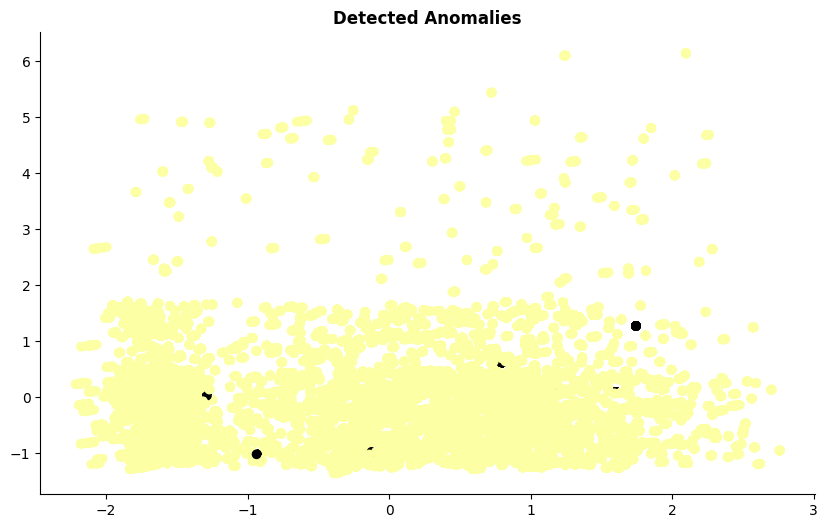

In [ ]:
# Set PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Visualize LOF anomalies
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=bank_df['lof_anomaly'],cmap='inferno')

plt.title('Detected Anomalies', fontweight="bold")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [ ]:
print("Comparing both methods:")
print("=======================================")
print("Isolation Forest:",(bank_df['Anomaly'] == -1).sum(),"anomalies")
print("Local Outlier Factor (LOF):", (bank_df['lof_anomaly'] == -1).sum(),"anomalies")

Comparing both methods:
Isolation Forest: 97 anomalies
Local Outlier Factor (LOF): 100 anomalies


### Findings

Compared to normal observations, anomalies tend to have:

- Lower transaction amounts
- Higher average account balances
- Older customers
- Longer transaction durations